# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment) with Hyperparameter Tuning

**Sri Sivasubramaniya Nadar College of Engineering, Chennai**  
**Subject:** ICS1512 – Machine Learning Algorithms Laboratory  
**Degree & Branch:** M.Tech (Integrated) Computer Science & Engineering | **Semester:** V | **Batch:** 2024–2029

---

## 1. Aim and Objective
To implement and compare the performance of

* **Model A:** Single-Layer Perceptron Learning Algorithm (PLA) – step activation, implemented from scratch.
* **Model B:** Multilayer Perceptron (MLP) with hidden layers and non-linear activations – implemented from scratch (NumPy) with back-propagation, and tuned systematically over activation function, cost function, optimizer, learning rate, batch size, number of hidden layers / neurons and L2 regularisation.

**Dataset:** English Handwritten Characters – 3,410 images, 62 classes (`0-9`, `A-Z`, `a-z`), 55 images per class.

**Evaluation:** Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC curves (micro / macro average) and training-error vs epochs curves.

## 2. Setup

In [1]:
import os, time, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, classification_report)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
sns.set_style("whitegrid")

## 3. Load the Dataset
The uploaded `archive.zip` contains an `Img/` folder (3,410 PNG images) and `english.csv` (image path → label).
The cell below extracts the zip (if it hasn't been extracted yet). **Change `ZIP_PATH` / `DATA_DIR` if your files are somewhere else** (e.g. on Google Colab: upload `archive.zip` to `/content`).

In [2]:
ZIP_PATH = "archive.zip"      # path to the uploaded zip
DATA_DIR = "english_chars"    # where it will be extracted

if not os.path.exists(os.path.join(DATA_DIR, "english.csv")):
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

df = pd.read_csv(os.path.join(DATA_DIR, "english.csv"))
print("Total images :", len(df))
print("Classes      :", df.label.nunique())
print("Images/class :", df.label.value_counts().unique())
df.head()

Total images : 3410
Classes      : 62
Images/class : [55]


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


## 4. Preprocessing (resize, flatten, normalise)
The raw images are 1200×900 RGB photos of a black handwritten character on a white background. Steps applied to every image:

1. **Grayscale** conversion (colour carries no information).
2. **Invert** so that the *ink* has high values and the background is 0 (sparse, zero-background inputs train better).
3. **Crop to the character's bounding box** and pad to a **square** with a 10 % margin – this removes position/scale variation and avoids distorting the aspect ratio.
4. **Resize to 28 × 28** (784 features).
5. **Scale to [0, 1]** (÷255), **flatten** to a 784-vector, and later **standardise** with the training-set mean/std.
6. **Stratified split** into 70 % train / 15 % validation / 15 % test. The validation set is used only for hyper-parameter tuning & early stopping; the test set is touched only once at the end.

In [3]:
IMG_SIZE = 28

def preprocess(path, size=IMG_SIZE, margin=0.10):
    img = Image.open(path).convert("L")                 # 1. grayscale
    a = 255 - np.asarray(img, dtype=np.float32)         # 2. invert (ink = high)
    ys, xs = np.where(a > 50)                           # 3. bounding box of the ink
    a = a[ys.min():ys.max()+1, xs.min():xs.max()+1]
    h, w = a.shape
    s = max(h, w); m = int(margin * s)
    canvas = np.zeros((s + 2*m, s + 2*m), dtype=np.float32)   # square canvas
    oy, ox = (s - h)//2 + m, (s - w)//2 + m
    canvas[oy:oy+h, ox:ox+w] = a
    small = Image.fromarray(canvas.astype(np.uint8)).resize((size, size), Image.BILINEAR)  # 4. resize
    return np.asarray(small, dtype=np.float32) / 255.0                                     # 5. [0,1]

CACHE = "preprocessed_28x28.npz"
if os.path.exists(CACHE):
    d = np.load(CACHE, allow_pickle=True); X_img, labels = d["X"], d["y"]
else:
    t0 = time.time()
    X_img = np.stack([preprocess(os.path.join(DATA_DIR, p)) for p in df.image])
    labels = df.label.astype(str).values
    np.savez_compressed(CACHE, X=X_img, y=labels)
    print(f"Preprocessed {len(X_img)} images in {time.time()-t0:.0f}s")

print("Image tensor:", X_img.shape, "| value range:", X_img.min(), "-", X_img.max())

Image tensor: (3410, 28, 28) | value range: 0.0 - 1.0


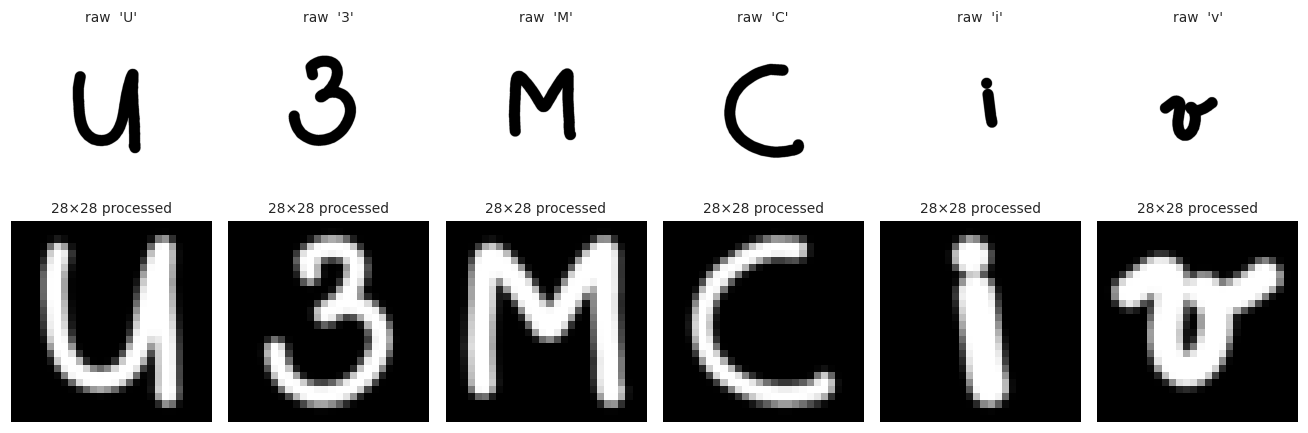

In [4]:
# Before / after preprocessing for a few random samples
rng = np.random.RandomState(1)
idx = rng.choice(len(df), 6, replace=False)
fig, ax = plt.subplots(2, 6, figsize=(12, 4.2))
for j, i in enumerate(idx):
    ax[0, j].imshow(Image.open(os.path.join(DATA_DIR, df.image[i])).convert("L"), cmap="gray")
    ax[0, j].set_title(f"raw  '{labels[i]}'", fontsize=9)
    ax[1, j].imshow(X_img[i], cmap="gray"); ax[1, j].set_title("28×28 processed", fontsize=9)
    ax[0, j].axis("off"); ax[1, j].axis("off")
plt.tight_layout(); plt.show()

In [5]:
# Encode labels, flatten, split, standardise
classes = sorted(np.unique(labels), key=lambda c: (0, c) if c.isdigit() else ((1, c) if c.isupper() else (2, c)))
cls2id = {c: i for i, c in enumerate(classes)}
y_all = np.array([cls2id[c] for c in labels])
K = len(classes)
X_all = X_img.reshape(len(X_img), -1)

X_tmp, X_test, y_tmp, y_test = train_test_split(X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=SEED)

mu, sd = X_train.mean(), X_train.std()          # global (scalar) statistics from TRAIN only
X_train, X_val, X_test = [(a - mu) / sd for a in (X_train, X_val, X_test)]

print(f"classes K={K} | features D={X_all.shape[1]}")
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")

classes K=62 | features D=784
train (2386, 784) | val (512, 784) | test (512, 784)


## 5. Evaluation helpers
Accuracy, macro-averaged Precision / Recall / F1, confusion matrix and micro / macro ROC curves (one-vs-rest, computed from each model's class scores).

In [6]:
def evaluate(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1-score":  f1_score(y_true, y_pred, average="macro", zero_division=0)}

def roc_micro_macro(y_true, scores):
    Y = label_binarize(y_true, classes=np.arange(K))
    fpr_mi, tpr_mi, _ = roc_curve(Y.ravel(), scores.ravel())
    fprs, tprs = {}, {}
    for k in range(K):
        fprs[k], tprs[k], _ = roc_curve(Y[:, k], scores[:, k])
    grid = np.linspace(0, 1, 500)
    tpr_ma = np.mean([np.interp(grid, fprs[k], tprs[k]) for k in range(K)], axis=0)
    return (fpr_mi, tpr_mi, auc(fpr_mi, tpr_mi)), (grid, tpr_ma, auc(grid, tpr_ma))

def plot_confusion(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))
    ax = ax or plt.gca()
    sns.heatmap(cm, ax=ax, cmap="Blues", cbar=True, xticklabels=classes, yticklabels=classes, square=True)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(labelsize=6); ax.grid(False)
    return cm

## 6. Model A – Single-Layer Perceptron (PLA) from scratch

**Theory.** Each output neuron computes a net input $z_k = \mathbf w_k^\top \mathbf x + b_k$ and applies the **step (Heaviside) activation** $\hat y_k = 1[z_k \ge 0]$.  
For 62 classes we use **62 perceptrons in parallel** (one-vs-rest, target = one-hot vector). After every sample the **perceptron learning rule** is applied:

$$\mathbf w_k \leftarrow \mathbf w_k + \eta\,(y_k - \hat y_k)\,\mathbf x \qquad b_k \leftarrow b_k + \eta\,(y_k-\hat y_k)$$

At prediction time the class with the largest net input $z_k$ is chosen (arg-max breaks ties when several / no neurons fire). The raw net inputs $z_k$ are also used as scores for the ROC curves.  
**Limitation:** the PLA converges only if the classes are linearly separable – handwritten characters are not.

In [7]:
class PerceptronPLA:
    # Multi-class single-layer perceptron: step activation + perceptron weight-update rule.
    def __init__(self, n_features, n_classes, lr=0.01, seed=SEED):
        self.rng = np.random.RandomState(seed)
        self.W = np.zeros((n_features + 1, n_classes))   # last row = bias
        self.lr, self.K = lr, n_classes

    @staticmethod
    def _aug(X): return np.hstack([X, np.ones((len(X), 1))])
    @staticmethod
    def step(z): return (z >= 0).astype(float)             # step activation

    def decision_function(self, X): return self._aug(X) @ self.W
    def predict(self, X): return self.decision_function(X).argmax(1)

    def fit(self, X, y, epochs=50, X_val=None, y_val=None):
        Xa, T = self._aug(X), np.eye(self.K)[y]
        self.history = {"train_err": [], "val_err": [], "mistakes": []}
        for ep in range(epochs):
            mistakes = 0
            for i in self.rng.permutation(len(Xa)):         # online (sample-by-sample) updates
                y_hat = self.step(Xa[i] @ self.W)           # step activation
                delta = T[i] - y_hat                        # (y - y_hat)
                if delta.any():
                    self.W += self.lr * np.outer(Xa[i], delta)   # w <- w + eta (y - y_hat) x
                    mistakes += 1
            self.history["mistakes"].append(mistakes)
            self.history["train_err"].append(1 - accuracy_score(y, self.predict(X)))
            if X_val is not None:
                self.history["val_err"].append(1 - accuracy_score(y_val, self.predict(X_val)))
        return self

In [8]:
# Train the PLA. With zero-initialised weights the learned decision boundary does not depend on the learning
# rate (eta only rescales W), so the number of epochs is the only knob that matters here.
t0 = time.time()
pla = PerceptronPLA(X_train.shape[1], K, lr=0.01).fit(X_train, y_train, epochs=60, X_val=X_val, y_val=y_val)
print(f"PLA trained in {time.time()-t0:.1f}s")
print(f"final train acc = {1-pla.history['train_err'][-1]:.4f} | val acc = {1-pla.history['val_err'][-1]:.4f}")

PLA trained in 10.5s
final train acc = 0.9828 | val acc = 0.6680


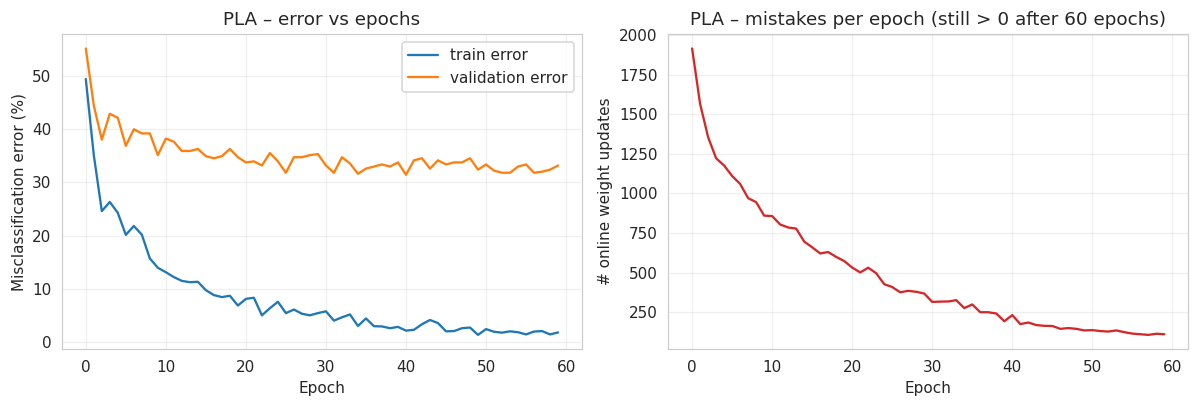

In [9]:
# PLA training-error vs epochs (convergence)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(np.array(pla.history["train_err"])*100, label="train error")
ax[0].plot(np.array(pla.history["val_err"])*100, label="validation error")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Misclassification error (%)"); ax[0].set_title("PLA – error vs epochs"); ax[0].legend()
ax[1].plot(pla.history["mistakes"], color="C3")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("# online weight updates"); ax[1].set_title("PLA – mistakes per epoch (still > 0 after 60 epochs)")
plt.tight_layout(); plt.show()

In [10]:
pla_test_pred  = pla.predict(X_test)
pla_test_score = pla.decision_function(X_test)
pla_metrics = evaluate(y_test, pla_test_pred)
print("PLA – TEST metrics"); print(pd.Series(pla_metrics).round(4).to_string())

PLA – TEST metrics
Accuracy     0.6934
Precision    0.7364
Recall       0.6940
F1-score     0.6928


## 7. Model B – Multilayer Perceptron (from scratch, NumPy)

**Architecture:** Input (784) → Hidden layer(s) with non-linear activation → Output (62, soft-max).  
**Forward pass:** $\mathbf a^{(l)} = f(\mathbf a^{(l-1)}W^{(l)}+\mathbf b^{(l)})$, output $\mathbf p=\text{softmax}(\mathbf z^{(L)})$.  
**Cost functions supported:** Cross-Entropy $-\frac1N\sum\sum y\log p$ and Mean-Squared-Error $\frac1N\sum\|\mathbf p-\mathbf y\|^2$.  
**Activations supported:** ReLU, Tanh, Sigmoid (weights: He init for ReLU, Xavier init otherwise).  
**Optimizers supported:** mini-batch SGD, SGD + Momentum (β = 0.9), Adam (β₁ = 0.9, β₂ = 0.999).  
**Extras:** L2 weight decay and early stopping on validation loss (restore best weights) for over-fitting control.  
**Learning:** gradients are obtained by **back-propagation**: $\delta^{(L)} = \partial \mathcal L/\partial \mathbf z^{(L)}$ and $\delta^{(l)}=(\delta^{(l+1)}W^{(l+1)\top})\odot f'(\mathbf z^{(l)})$.

In [11]:
class MLP:
    def __init__(self, n_in, hidden, n_out, activation="relu", loss="cross_entropy",
                 optimizer="adam", lr=1e-3, batch_size=64, l2=0.0, seed=SEED):
        self.act, self.loss_name, self.opt, self.lr = activation, loss, optimizer, lr
        self.bs, self.l2, self.rng = batch_size, l2, np.random.RandomState(seed)
        sizes = [n_in] + list(hidden) + [n_out]
        self.W, self.b = [], []
        for i, o in zip(sizes[:-1], sizes[1:]):
            scale = np.sqrt(2.0 / i) if activation == "relu" else np.sqrt(1.0 / i)   # He / Xavier
            self.W.append(self.rng.randn(i, o) * scale); self.b.append(np.zeros(o))
        self._init_opt()

    # ---------- activations ----------
    def _f(self, z):
        if self.act == "relu":    return np.maximum(0, z)
        if self.act == "tanh":    return np.tanh(z)
        if self.act == "sigmoid": return 1 / (1 + np.exp(-np.clip(z, -50, 50)))
    def _df(self, z, a):
        if self.act == "relu":    return (z > 0).astype(z.dtype)
        if self.act == "tanh":    return 1 - a**2
        if self.act == "sigmoid": return a * (1 - a)

    @staticmethod
    def _softmax(z):
        z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

    # ---------- forward / loss ----------
    def forward(self, X):
        zs, As = [], [X]
        for l in range(len(self.W) - 1):
            z = As[-1] @ self.W[l] + self.b[l]; zs.append(z); As.append(self._f(z))
        p = self._softmax(As[-1] @ self.W[-1] + self.b[-1])
        return zs, As, p

    def loss(self, p, Y):
        if self.loss_name == "cross_entropy":
            return -np.mean(np.sum(Y * np.log(p + 1e-12), axis=1))
        return np.mean(np.sum((p - Y) ** 2, axis=1))                     # MSE

    def predict_proba(self, X): return self.forward(X)[2]
    def predict(self, X): return self.predict_proba(X).argmax(1)

    # ---------- back-propagation ----------
    def gradients(self, X, Y):
        zs, As, p = self.forward(X); N = len(X)
        if self.loss_name == "cross_entropy":
            dz = (p - Y) / N                                              # softmax + CE
        else:
            g = 2 * (p - Y) / N                                           # dL/dp
            dz = p * (g - np.sum(g * p, axis=1, keepdims=True))           # through softmax
        gW, gb = [None] * len(self.W), [None] * len(self.W)
        for l in reversed(range(len(self.W))):
            gW[l] = As[l].T @ dz + self.l2 * self.W[l]
            gb[l] = dz.sum(0)
            if l > 0:
                dz = (dz @ self.W[l].T) * self._df(zs[l - 1], As[l])
        return gW, gb

    # ---------- optimizers ----------
    def _init_opt(self):
        self.t = 0
        self.mW = [np.zeros_like(w) for w in self.W]; self.mb = [np.zeros_like(b) for b in self.b]
        self.vW = [np.zeros_like(w) for w in self.W]; self.vb = [np.zeros_like(b) for b in self.b]

    def _step(self, gW, gb):
        self.t += 1
        for l in range(len(self.W)):
            if self.opt == "sgd":
                self.W[l] -= self.lr * gW[l]; self.b[l] -= self.lr * gb[l]
            elif self.opt == "momentum":
                self.mW[l] = 0.9 * self.mW[l] + gW[l]; self.mb[l] = 0.9 * self.mb[l] + gb[l]
                self.W[l] -= self.lr * self.mW[l];     self.b[l] -= self.lr * self.mb[l]
            elif self.opt == "adam":
                b1, b2, eps = 0.9, 0.999, 1e-8
                for P, g, m, v in ((self.W, gW, self.mW, self.vW), (self.b, gb, self.mb, self.vb)):
                    m[l] = b1 * m[l] + (1 - b1) * g[l]; v[l] = b2 * v[l] + (1 - b2) * g[l] ** 2
                    mh, vh = m[l] / (1 - b1 ** self.t), v[l] / (1 - b2 ** self.t)
                    P[l] -= self.lr * mh / (np.sqrt(vh) + eps)

    # ---------- training loop ----------
    def fit(self, X, y, X_val=None, y_val=None, epochs=60, patience=10, verbose=False):
        Y = np.eye(self.W[-1].shape[1])[y]
        Yv = np.eye(self.W[-1].shape[1])[y_val] if X_val is not None else None
        h = {k: [] for k in ("train_loss", "val_loss", "train_acc", "val_acc")}
        best, best_ep, best_params, wait = np.inf, 0, None, 0
        for ep in range(epochs):
            perm = self.rng.permutation(len(X))
            for s in range(0, len(X), self.bs):
                idx = perm[s:s + self.bs]
                gW, gb = self.gradients(X[idx], Y[idx]); self._step(gW, gb)
            p = self.predict_proba(X)
            h["train_loss"].append(self.loss(p, Y)); h["train_acc"].append((p.argmax(1) == y).mean())
            if X_val is not None:
                pv = self.predict_proba(X_val)
                h["val_loss"].append(self.loss(pv, Yv)); h["val_acc"].append((pv.argmax(1) == y_val).mean())
                if h["val_loss"][-1] < best - 1e-5:
                    best, best_ep, wait = h["val_loss"][-1], ep, 0
                    best_params = ([w.copy() for w in self.W], [b.copy() for b in self.b])
                else:
                    wait += 1
                    if patience and wait >= patience: break            # early stopping
            if verbose and ep % 10 == 0: print(ep, h["train_loss"][-1])
        if best_params is not None and patience:                       # restore best weights (only when early stopping is on)
            self.W, self.b = best_params
        self.best_epoch, self.history = best_ep, h
        return self

### 7.1 Sanity check of back-propagation (numerical gradient check)
Before training, we verify the analytic gradients against finite differences for every activation / loss combination – relative error should be ≪ 1e-5.

In [12]:
def grad_check(act, loss):
    r = np.random.RandomState(0)
    Xs, ys = r.randn(6, 10), r.randint(0, 4, 6); Ys = np.eye(4)[ys]
    m = MLP(10, [7, 5], 4, activation=act, loss=loss, optimizer="sgd", l2=0.0, seed=1)
    gW, gb = m.gradients(Xs, Ys)
    worst = 0
    for l in range(len(m.W)):
        for _ in range(5):
            i, j = r.randint(m.W[l].shape[0]), r.randint(m.W[l].shape[1]); eps = 1e-5
            m.W[l][i, j] += eps; lp = m.loss(m.forward(Xs)[2], Ys)
            m.W[l][i, j] -= 2*eps; lm = m.loss(m.forward(Xs)[2], Ys)
            m.W[l][i, j] += eps
            num = (lp - lm) / (2*eps)
            worst = max(worst, abs(num - gW[l][i, j]) / max(1e-8, abs(num) + abs(gW[l][i, j])))
    return worst

rows = [(a, l, grad_check(a, l)) for a in ("relu", "tanh", "sigmoid") for l in ("cross_entropy", "mse")]
pd.DataFrame(rows, columns=["activation", "loss", "max relative error"]).style.format({"max relative error": "{:.2e}"})

,activation,loss,max relative error
0,relu,cross_entropy,6.19e-09
1,relu,mse,1.00e-08
2,tanh,cross_entropy,1.30e-09
3,tanh,mse,3.78e-09
4,sigmoid,cross_entropy,1.34e-08
5,sigmoid,mse,1.62e-08


## 8. Hyper-parameter tuning (systematic, stage-wise search)
A full grid over all hyper-parameters is expensive, so we tune **one group at a time** (coordinate / stage-wise search), always carrying the best value of the previous stage forward. Every configuration is trained on the **training set** with early stopping on the validation loss (max 60 epochs, patience 10) and is scored by **validation accuracy** at the best epoch.

| Stage | Hyper-parameters searched | Values |
|---|---|---|
| 1 | Optimizer × Learning rate | SGD / Momentum / Adam × {0.001, 0.01, 0.1} |
| 2 | Activation × Cost function | ReLU / Tanh / Sigmoid × Cross-Entropy / MSE |
| 3 | Batch size | 16, 32, 64, 128, 256 |
| 4 | Hidden layers & neurons | 1–3 hidden layers, 64–256 neurons |
| 5 | L2 regularisation | 0, 1e-4, 1e-3, 1e-2 |

Starting point (base configuration): `[128]` hidden neurons, ReLU, Cross-Entropy, batch = 64.

In [13]:
D = X_train.shape[1]
ALL_RUNS, HISTORIES = [], {}

def run_config(stage, **cfg):
    full = dict(hidden=(128,), activation="relu", loss="cross_entropy", optimizer="adam",
                lr=1e-3, batch_size=64, l2=0.0); full.update(cfg)
    t0 = time.time()
    m = MLP(D, full["hidden"], K, activation=full["activation"], loss=full["loss"], optimizer=full["optimizer"],
            lr=full["lr"], batch_size=full["batch_size"], l2=full["l2"]).fit(X_train, y_train, X_val, y_val, epochs=60, patience=10)
    be = m.best_epoch
    rec = dict(stage=stage, **{k: (str(v) if k == "hidden" else v) for k, v in full.items()},
               best_epoch=be + 1, train_acc=m.history["train_acc"][be], val_acc=m.history["val_acc"][be],
               val_loss=m.history["val_loss"][be], time_s=time.time() - t0)
    ALL_RUNS.append(rec); HISTORIES[len(ALL_RUNS) - 1] = m.history
    return rec, full

def run_stage(stage, grid, base):
    recs = []
    for g in grid:
        rec, full = run_config(stage, **{**base, **g}); rec["_full"] = full; recs.append(rec)
    res = pd.DataFrame(recs)
    best = res.sort_values(["val_acc", "val_loss"], ascending=[False, True]).iloc[0]
    return res, dict(best["_full"])

BASE = dict()

### Stage 1 – Optimizer × Learning rate

,optimizer,lr,best_epoch,train_acc,val_acc,val_loss,time_s
4,momentum,0.010000,18,0.967,0.756,0.936,3.8
6,adam,0.001000,12,0.957,0.740,0.933,4.3
2,sgd,0.100000,18,0.969,0.738,0.934,3.4
3,momentum,0.001000,58,0.932,0.729,0.936,8.0
1,sgd,0.010000,57,0.928,0.727,0.941,7.4
7,adam,0.010000,4,0.842,0.686,1.192,2.8
5,momentum,0.100000,3,0.711,0.590,1.629,1.7
0,sgd,0.001000,60,0.645,0.543,1.802,7.5
8,adam,0.100000,2,0.019,0.021,4.120,2.3


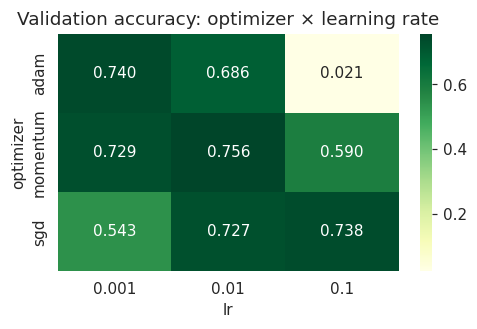

→ best so far: {'optimizer': 'momentum', 'lr': 0.01}


In [14]:
grid = [dict(optimizer=o, lr=lr) for o in ("sgd", "momentum", "adam") for lr in (0.001, 0.01, 0.1)]
res1, BASE = run_stage("1_opt_lr", grid, BASE)
show = ["optimizer", "lr", "best_epoch", "train_acc", "val_acc", "val_loss", "time_s"]
display(res1[show].sort_values("val_acc", ascending=False).style.format({"train_acc":"{:.3f}","val_acc":"{:.3f}","val_loss":"{:.3f}","time_s":"{:.1f}"}).background_gradient(subset=["val_acc"], cmap="Greens"))
piv = res1.pivot(index="optimizer", columns="lr", values="val_acc")
plt.figure(figsize=(5, 2.8)); sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGn"); plt.title("Validation accuracy: optimizer × learning rate"); plt.show()
print("→ best so far:", {k: BASE[k] for k in ("optimizer", "lr")})

### Stage 2 – Activation function × Cost function

,activation,loss,best_epoch,train_acc,val_acc,val_loss,time_s
2,tanh,cross_entropy,30,0.976,0.771,0.822,5.4
0,relu,cross_entropy,18,0.967,0.756,0.936,3.7
4,sigmoid,cross_entropy,59,0.907,0.754,0.843,8.5
3,tanh,mse,59,0.906,0.732,0.367,8.4
1,relu,mse,43,0.825,0.650,0.458,7.1
5,sigmoid,mse,60,0.435,0.410,0.763,8.5


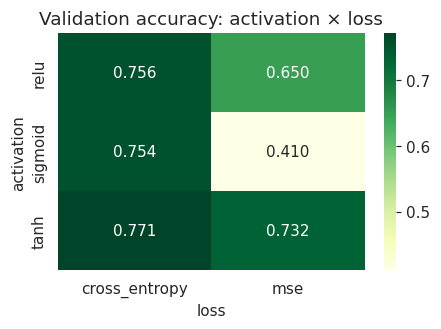

→ best so far: {'optimizer': 'momentum', 'lr': 0.01, 'activation': 'tanh', 'loss': 'cross_entropy'}


In [15]:
grid = [dict(activation=a, loss=l) for a in ("relu", "tanh", "sigmoid") for l in ("cross_entropy", "mse")]
res2, BASE = run_stage("2_act_loss", grid, BASE)
show = ["activation", "loss", "best_epoch", "train_acc", "val_acc", "val_loss", "time_s"]
display(res2[show].sort_values("val_acc", ascending=False).style.format({"train_acc":"{:.3f}","val_acc":"{:.3f}","val_loss":"{:.3f}","time_s":"{:.1f}"}).background_gradient(subset=["val_acc"], cmap="Greens"))
piv = res2.pivot(index="activation", columns="loss", values="val_acc")
plt.figure(figsize=(4.5, 2.8)); sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGn"); plt.title("Validation accuracy: activation × loss"); plt.show()
print("→ best so far:", {k: BASE[k] for k in ("optimizer", "lr", "activation", "loss")})

### Stage 3 – Batch size

In [16]:
grid = [dict(batch_size=b) for b in (16, 32, 64, 128, 256)]
res3, BASE = run_stage("3_batch", grid, BASE)
show = ["batch_size", "best_epoch", "train_acc", "val_acc", "val_loss", "time_s"]
display(res3[show].style.format({"train_acc":"{:.3f}","val_acc":"{:.3f}","val_loss":"{:.3f}","time_s":"{:.1f}"}).background_gradient(subset=["val_acc"], cmap="Greens"))
print("→ best batch size:", BASE["batch_size"])

,batch_size,best_epoch,train_acc,val_acc,val_loss,time_s
0,16,9,0.965,0.760,0.814,4.9
1,32,21,0.977,0.771,0.817,5.5
2,64,30,0.976,0.771,0.822,5.4
3,128,60,0.978,0.766,0.820,6.8
4,256,58,0.945,0.754,0.849,6.3


→ best batch size: 32


### Stage 4 – Number of hidden layers and neurons

,hidden,n_hidden_layers,best_epoch,train_acc,val_acc,val_loss,time_s
0,"(64,)",1,22,0.973,0.764,0.888,3.1
1,"(128,)",1,21,0.977,0.771,0.817,5.4
2,"(256,)",1,16,0.982,0.787,0.791,8.5
3,"(128, 64)",2,19,0.977,0.748,0.837,5.4
4,"(256, 128)",2,13,0.965,0.762,0.805,8.6
5,"(256, 128, 64)",3,18,0.977,0.748,0.788,10.9
6,"(128, 128, 128)",3,12,0.965,0.758,0.838,5.2


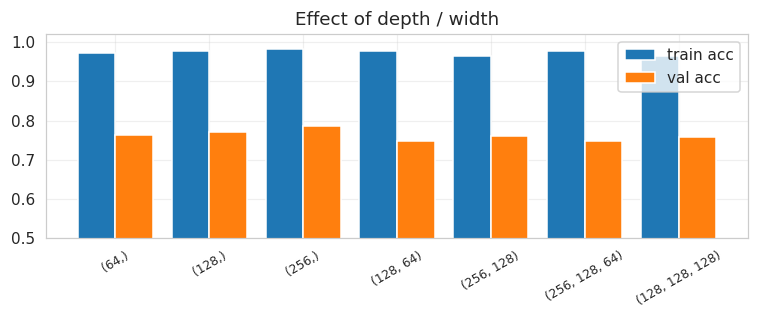

→ best architecture: (256,)


In [17]:
grid = [dict(hidden=h) for h in [(64,), (128,), (256,), (128, 64), (256, 128), (256, 128, 64), (128, 128, 128)]]
res4, BASE = run_stage("4_arch", grid, BASE)
res4["n_hidden_layers"] = res4["hidden"].apply(lambda s: len(eval(s)))
show = ["hidden", "n_hidden_layers", "best_epoch", "train_acc", "val_acc", "val_loss", "time_s"]
display(res4[show].style.format({"train_acc":"{:.3f}","val_acc":"{:.3f}","val_loss":"{:.3f}","time_s":"{:.1f}"}).background_gradient(subset=["val_acc"], cmap="Greens"))
plt.figure(figsize=(7, 3)); x = np.arange(len(res4))
plt.bar(x - .2, res4.train_acc, .4, label="train acc"); plt.bar(x + .2, res4.val_acc, .4, label="val acc")
plt.xticks(x, res4.hidden, rotation=30, fontsize=8); plt.ylim(0.5, 1.02); plt.legend(); plt.title("Effect of depth / width"); plt.tight_layout(); plt.show()
print("→ best architecture:", BASE["hidden"])

### Stage 5 – L2 regularisation

In [18]:
grid = [dict(l2=v) for v in (0.0, 1e-4, 1e-3, 1e-2)]
res5, BASE = run_stage("5_l2", grid, BASE)
show = ["l2", "best_epoch", "train_acc", "val_acc", "val_loss", "time_s"]
display(res5[show].style.format({"train_acc":"{:.3f}","val_acc":"{:.3f}","val_loss":"{:.3f}","time_s":"{:.1f}"}).background_gradient(subset=["val_acc"], cmap="Greens"))
print("→ best L2:", BASE["l2"])

,l2,best_epoch,train_acc,val_acc,val_loss,time_s
0,0.000000,16,0.982,0.787,0.791,8.4
1,0.000100,16,0.982,0.787,0.791,8.4
2,0.001000,16,0.977,0.787,0.785,8.4
3,0.010000,39,0.949,0.779,0.801,15.9


→ best L2: 0.001


In [19]:
BEST = {k: (tuple(v) if k == "hidden" else v) for k, v in BASE.items()}
print("FINAL CHOSEN HYPER-PARAMETERS")
print(pd.Series(BEST).to_string())
tuning_log = pd.DataFrame(ALL_RUNS)
print(f"\nTotal configurations trained: {len(tuning_log)}")

FINAL CHOSEN HYPER-PARAMETERS
hidden               (256,)
activation             tanh
loss          cross_entropy
optimizer          momentum
lr                     0.01
batch_size               32
l2                    0.001

Total configurations trained: 31


### 8.1 Which hyper-parameter mattered most?
For each stage we compare the **spread (max − min) of validation accuracy** obtained by varying only that group of hyper-parameters. A larger spread ⇒ larger influence on performance.

,min,max,spread
Optimizer × LR,0.021,0.756,0.734
Activation × Loss,0.410,0.771,0.361
Batch size,0.754,0.771,0.018
Depth / width,0.748,0.787,0.039
L2 regularisation,0.779,0.787,0.008


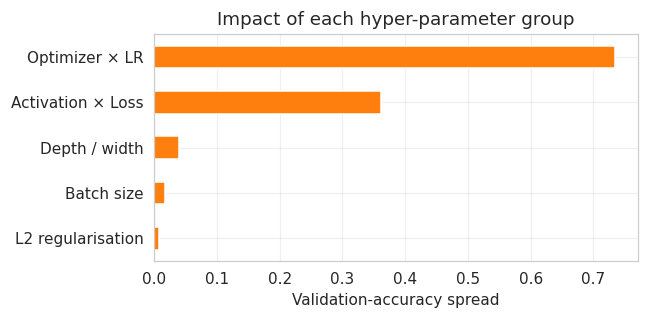

In [20]:
names = {"1_opt_lr": "Optimizer × LR", "2_act_loss": "Activation × Loss", "3_batch": "Batch size",
         "4_arch": "Depth / width", "5_l2": "L2 regularisation"}
imp = tuning_log.groupby("stage").val_acc.agg(["min", "max"]); imp["spread"] = imp["max"] - imp["min"]
imp.index = [names[i] for i in imp.index]
display(imp.style.format("{:.3f}"))
imp["spread"].sort_values().plot.barh(color="C1", figsize=(6, 3)); plt.xlabel("Validation-accuracy spread"); plt.title("Impact of each hyper-parameter group"); plt.tight_layout(); plt.show()

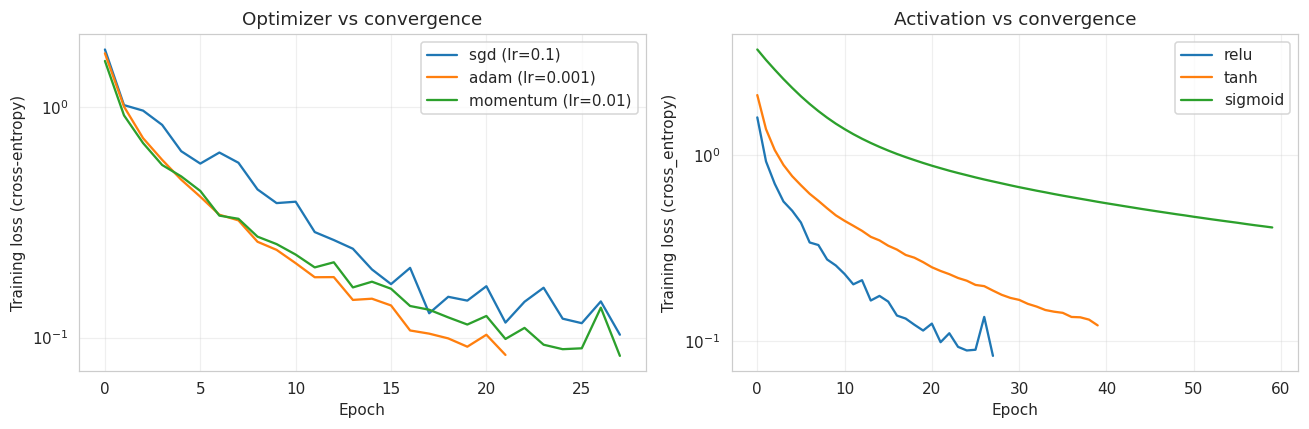

In [21]:
# Convergence: effect of optimizer (stage 1, best LR for each optimizer) and activation (stage 2)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
best_per_opt = res1.sort_values("val_acc").groupby("optimizer").tail(1)
for _, r in best_per_opt.iterrows():
    i = tuning_log.index[(tuning_log.stage == "1_opt_lr") & (tuning_log.optimizer == r.optimizer) & (tuning_log.lr == r.lr)][0]
    ax[0].plot(HISTORIES[i]["train_loss"], label=f"{r.optimizer} (lr={r.lr})")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Training loss (cross-entropy)"); ax[0].set_yscale("log"); ax[0].set_title("Optimizer vs convergence"); ax[0].legend()
for a_ in ("relu", "tanh", "sigmoid"):
    r = res2[(res2.activation == a_) & (res2.loss == BASE["loss"])].iloc[0]
    i = tuning_log.index[(tuning_log.stage == "2_act_loss") & (tuning_log.activation == a_) & (tuning_log.loss == BASE["loss"])][0]
    ax[1].plot(HISTORIES[i]["train_loss"], label=a_)
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel(f"Training loss ({BASE['loss']})"); ax[1].set_yscale("log"); ax[1].set_title("Activation vs convergence"); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Model B – Final tuned MLP
The best configuration is retrained (train set, early stopping on the validation set) and evaluated **once** on the untouched test set.

In [22]:
t0 = time.time()
mlp = MLP(D, BEST["hidden"], K, activation=BEST["activation"], loss=BEST["loss"], optimizer=BEST["optimizer"],
          lr=BEST["lr"], batch_size=BEST["batch_size"], l2=BEST["l2"]).fit(X_train, y_train, X_val, y_val, epochs=100, patience=15)
print(f"Trained in {time.time()-t0:.1f}s | stopped/best epoch = {mlp.best_epoch+1} | epochs run = {len(mlp.history['train_loss'])}")

mlp_test_pred  = mlp.predict(X_test)
mlp_test_score = mlp.predict_proba(X_test)
mlp_metrics = evaluate(y_test, mlp_test_pred)
print("\nTuned MLP – TEST metrics"); print(pd.Series(mlp_metrics).round(4).to_string())

Trained in 10.2s | stopped/best epoch = 16 | epochs run = 31

Tuned MLP – TEST metrics
Accuracy     0.7715
Precision    0.7910
Recall       0.7717
F1-score     0.7664


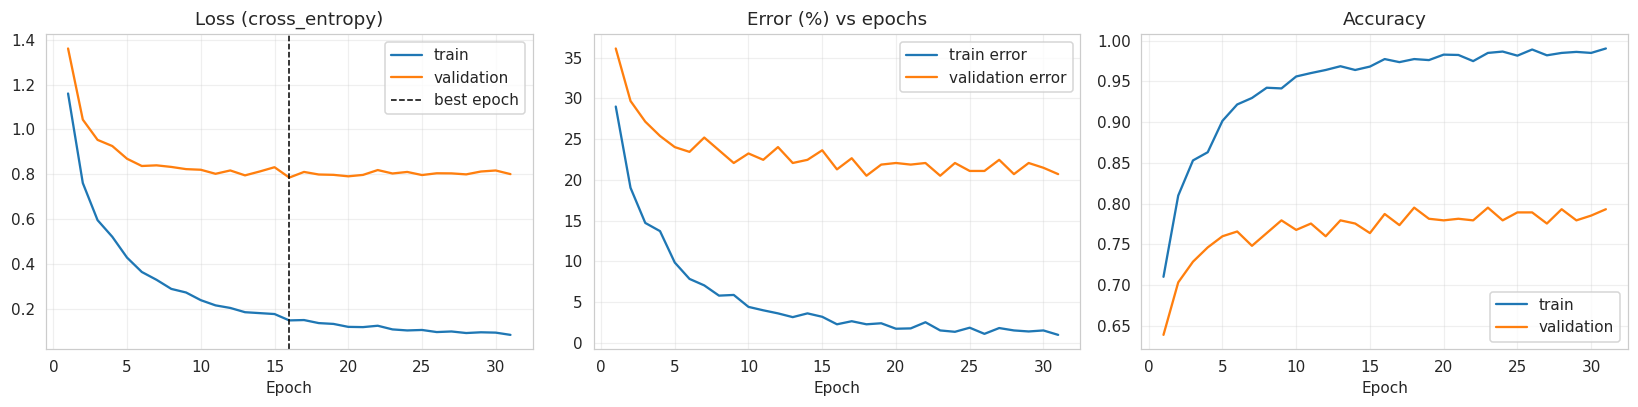

In [23]:
# Training / validation curves of the tuned MLP
h = mlp.history; ep = np.arange(1, len(h["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(ep, h["train_loss"], label="train"); ax[0].plot(ep, h["val_loss"], label="validation")
ax[0].axvline(mlp.best_epoch + 1, color="k", ls="--", lw=1, label="best epoch"); ax[0].set_title(f"Loss ({BEST['loss']})"); ax[0].legend()
ax[1].plot(ep, 100*(1-np.array(h["train_acc"])), label="train error"); ax[1].plot(ep, 100*(1-np.array(h["val_acc"])), label="validation error")
ax[1].set_title("Error (%) vs epochs"); ax[1].legend()
ax[2].plot(ep, h["train_acc"], label="train"); ax[2].plot(ep, h["val_acc"], label="validation"); ax[2].set_title("Accuracy"); ax[2].legend()
for a in ax: a.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

## 10. A/B Comparison: PLA (Model A) vs tuned MLP (Model B)
### 10.1 Metrics on the test set

,Accuracy,Precision,Recall,F1-score,Accuracy gain (B−A)
A: PLA (single layer),0.6934,0.7364,0.6940,0.6928,–
B: MLP (tuned),0.7715,0.7910,0.7717,0.7664,0.0781


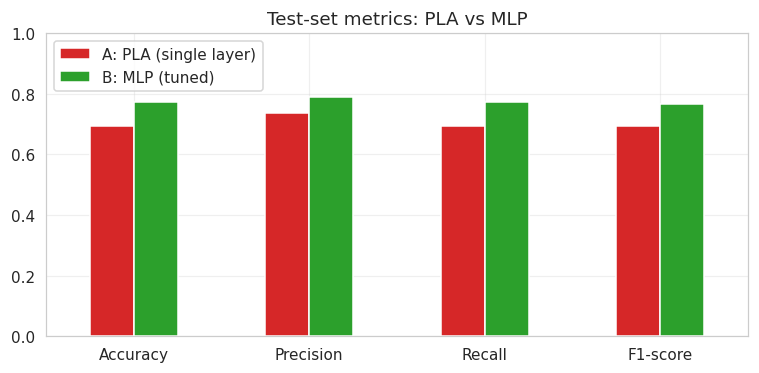

In [24]:
cmp = pd.DataFrame({"A: PLA (single layer)": pla_metrics, "B: MLP (tuned)": mlp_metrics}).T
cmp["Accuracy gain (B−A)"] = np.nan
cmp.loc["B: MLP (tuned)", "Accuracy gain (B−A)"] = mlp_metrics["Accuracy"] - pla_metrics["Accuracy"]
display(cmp.style.format("{:.4f}", na_rep="–").background_gradient(subset=["Accuracy", "Precision", "Recall", "F1-score"], cmap="Greens"))

cmp[["Accuracy", "Precision", "Recall", "F1-score"]].T.plot.bar(figsize=(7, 3.5), rot=0, color=["C3", "C2"])
plt.ylim(0, 1); plt.title("Test-set metrics: PLA vs MLP"); plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

In [25]:
print("Hyper-parameters chosen for the MLP:"); print(pd.Series(BEST).to_string())
print("\n--- Per-class report (MLP, test set) ---")
rep = pd.DataFrame(classification_report(y_test, mlp_test_pred, target_names=classes, output_dict=True, zero_division=0)).T
display(rep.round(3).head(62).style.background_gradient(subset=["f1-score"], cmap="Greens"))

Hyper-parameters chosen for the MLP:
hidden               (256,)
activation             tanh
loss          cross_entropy
optimizer          momentum
lr                     0.01
batch_size               32
l2                    0.001

--- Per-class report (MLP, test set) ---


,precision,recall,f1-score,support
0,0.571000,0.500000,0.533000,8.000000
1,0.800000,0.500000,0.615000,8.000000
2,0.875000,0.875000,0.875000,8.000000
3,0.875000,0.875000,0.875000,8.000000
4,0.875000,0.875000,0.875000,8.000000
5,1.000000,0.750000,0.857000,8.000000
6,1.000000,0.750000,0.857000,8.000000
7,0.900000,1.000000,0.947000,9.000000
8,0.857000,0.750000,0.800000,8.000000
9,0.875000,0.875000,0.875000,8.000000


### 10.2 Confusion matrices (test set)

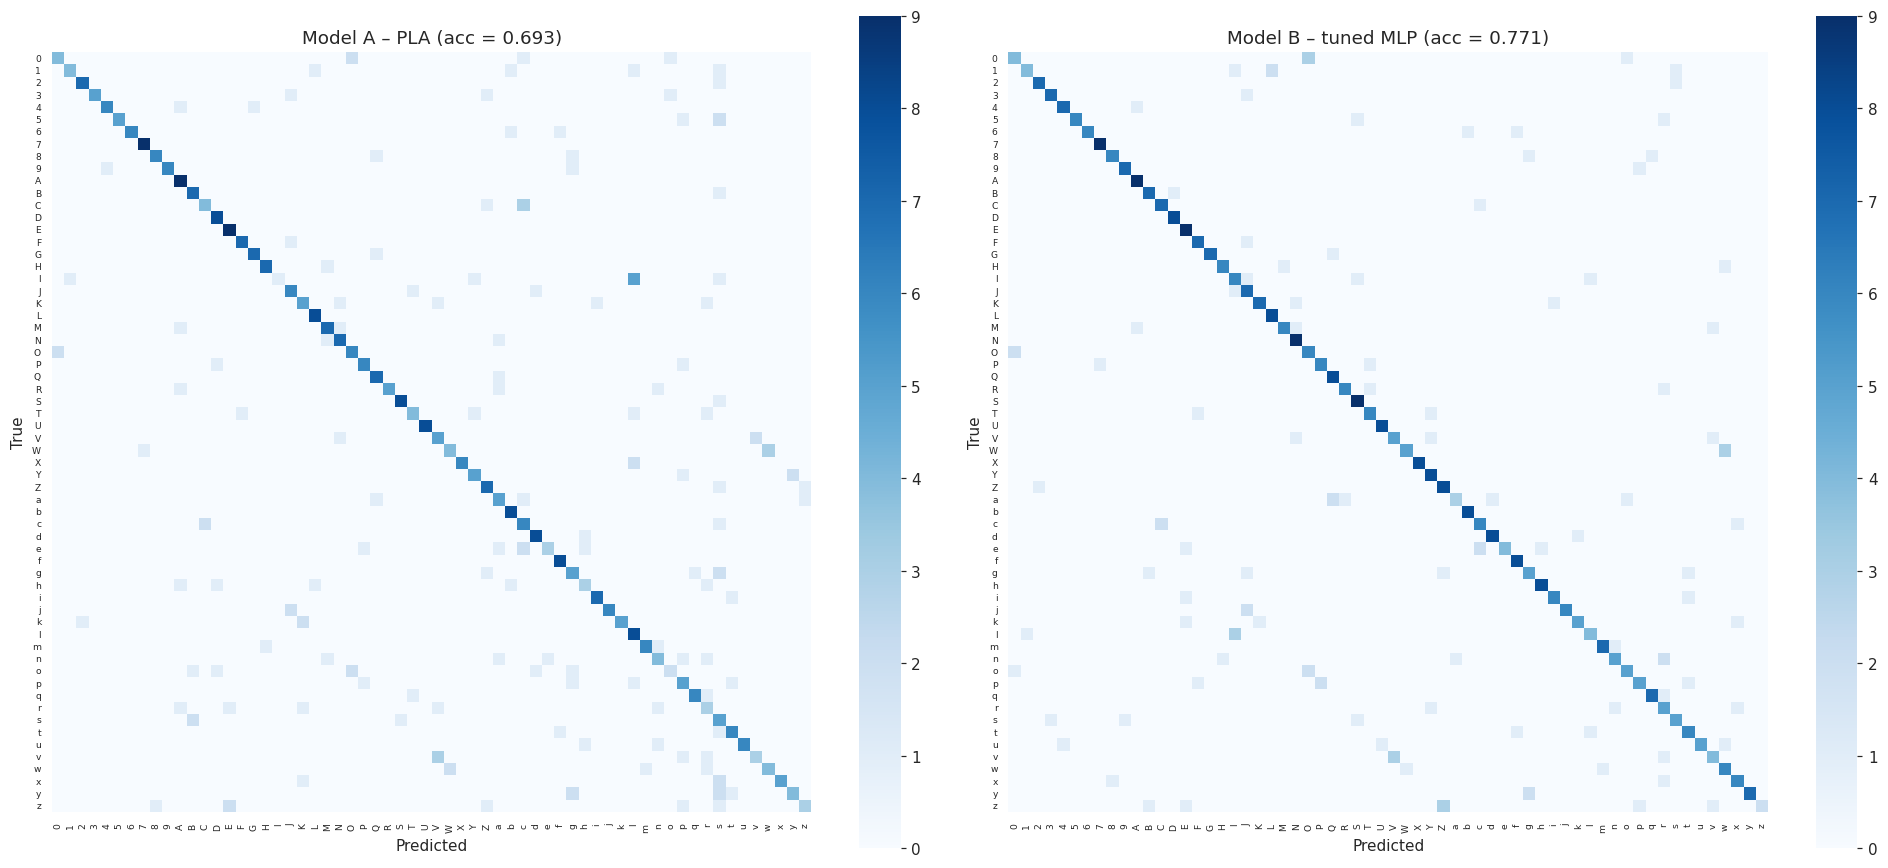

Most confused pairs for the MLP (true → predicted : count)
  'v' → 'V' : 3
  'l' → 'I' : 3
  'W' → 'w' : 3
  'z' → 'Z' : 3
  '0' → 'O' : 3
  'j' → 'J' : 2
  'p' → 'P' : 2
  'y' → 'g' : 2


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
cm_pla = plot_confusion(y_test, pla_test_pred, f"Model A – PLA (acc = {pla_metrics['Accuracy']:.3f})", ax[0])
cm_mlp = plot_confusion(y_test, mlp_test_pred, f"Model B – tuned MLP (acc = {mlp_metrics['Accuracy']:.3f})", ax[1])
plt.tight_layout(); plt.show()

# Most confused class pairs for the MLP
off = cm_mlp.copy(); np.fill_diagonal(off, 0)
top = np.dstack(np.unravel_index(np.argsort(-off.ravel())[:8], off.shape))[0]
print("Most confused pairs for the MLP (true → predicted : count)")
for t, p in top: print(f"  '{classes[t]}' → '{classes[p]}' : {off[t, p]}")

### 10.3 ROC curves (one-vs-rest, micro & macro average)

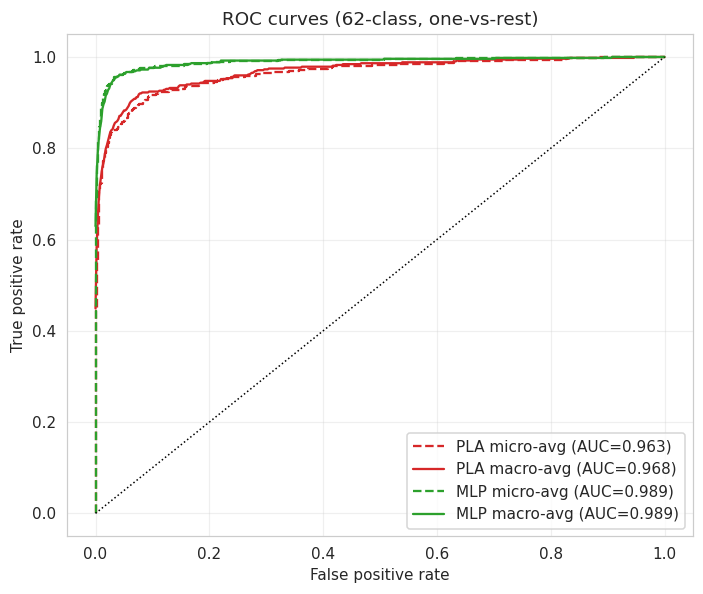

In [27]:
(pla_mi, pla_ma) = roc_micro_macro(y_test, pla_test_score)
(mlp_mi, mlp_ma) = roc_micro_macro(y_test, mlp_test_score)

plt.figure(figsize=(6.5, 5.5))
plt.plot(pla_mi[0], pla_mi[1], "--", color="C3", label=f"PLA micro-avg (AUC={pla_mi[2]:.3f})")
plt.plot(pla_ma[0], pla_ma[1], "-",  color="C3", label=f"PLA macro-avg (AUC={pla_ma[2]:.3f})")
plt.plot(mlp_mi[0], mlp_mi[1], "--", color="C2", label=f"MLP micro-avg (AUC={mlp_mi[2]:.3f})")
plt.plot(mlp_ma[0], mlp_ma[1], "-",  color="C2", label=f"MLP macro-avg (AUC={mlp_ma[2]:.3f})")
plt.plot([0, 1], [0, 1], "k:", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC curves (62-class, one-vs-rest)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

### 10.4 Training error vs epochs (convergence)

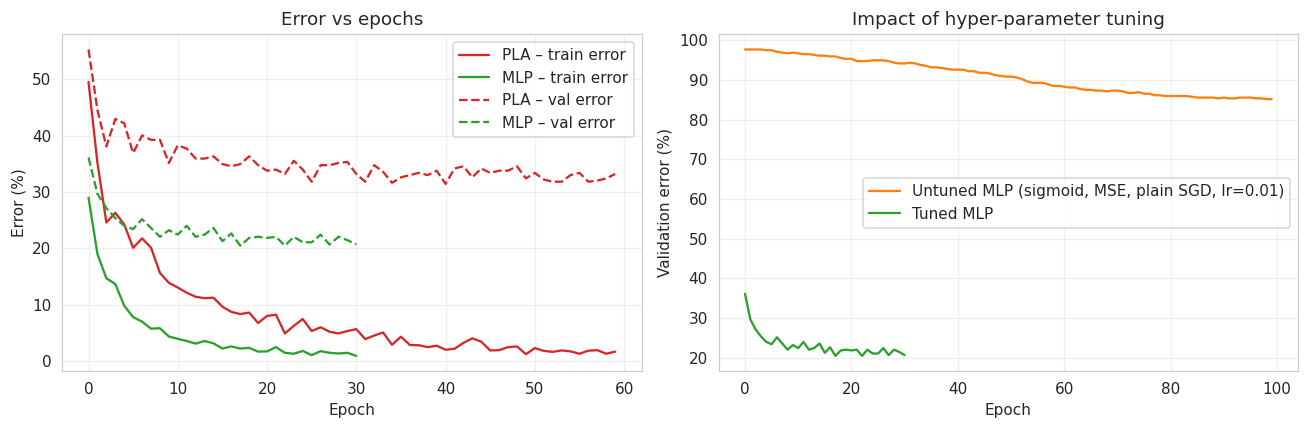

Test accuracy – PLA: 0.6934 | untuned MLP: 0.1426 | tuned MLP: 0.7715


In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.array(pla.history["train_err"]) * 100, color="C3", label="PLA – train error")
ax[0].plot(100 * (1 - np.array(mlp.history["train_acc"])), color="C2", label="MLP – train error")
ax[0].plot(np.array(pla.history["val_err"]) * 100, color="C3", ls="--", label="PLA – val error")
ax[0].plot(100 * (1 - np.array(mlp.history["val_acc"])), color="C2", ls="--", label="MLP – val error")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Error (%)"); ax[0].set_title("Error vs epochs"); ax[0].legend()

# effect of tuning: a deliberately naive MLP (sigmoid + MSE + plain SGD, small LR) vs the tuned MLP
base_untuned = MLP(D, (128,), K, activation="sigmoid", loss="mse", optimizer="sgd", lr=0.01, batch_size=64).fit(
    X_train, y_train, X_val, y_val, epochs=100, patience=0)          # no early stopping – shows raw convergence speed
ax[1].plot(100 * (1 - np.array(base_untuned.history["val_acc"])), color="C1", label="Untuned MLP (sigmoid, MSE, plain SGD, lr=0.01)")
ax[1].plot(100 * (1 - np.array(mlp.history["val_acc"])), color="C2", label="Tuned MLP")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Validation error (%)"); ax[1].set_title("Impact of hyper-parameter tuning"); ax[1].legend()
plt.tight_layout(); plt.show()

untuned_acc = accuracy_score(y_test, base_untuned.predict(X_test))
print(f"Test accuracy – PLA: {pla_metrics['Accuracy']:.4f} | untuned MLP: {untuned_acc:.4f} | tuned MLP: {mlp_metrics['Accuracy']:.4f}")

## 11. Over-fitting analysis and mitigation
We compare the tuned MLP with the **same** network trained **without** L2 and **without** early stopping for a long run (100 epochs) to show the over-fitting behaviour, then show what regularisation / early stopping do.

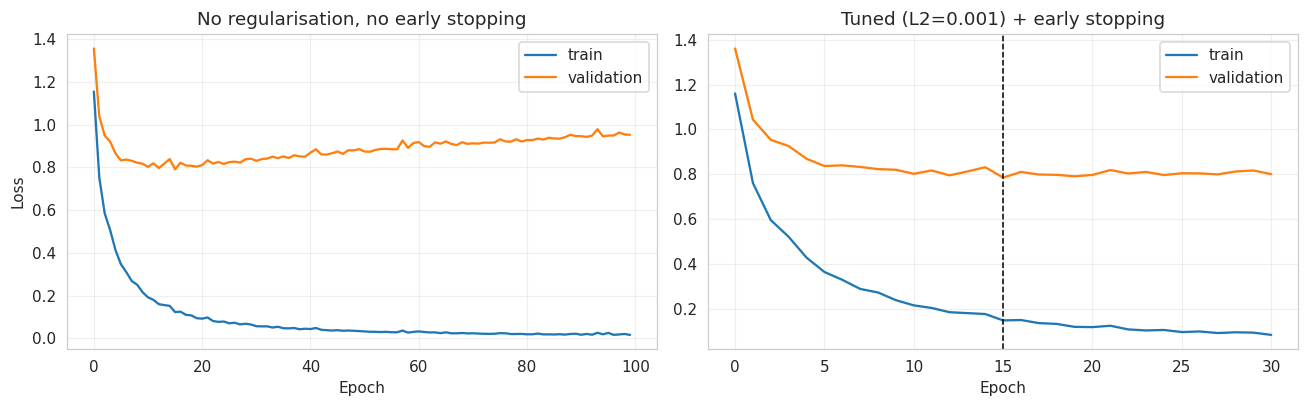

Train–val accuracy gap  |  no reg. (final epoch): 0.208   |  tuned (best epoch): 0.190
Test accuracy           |  no reg. (final epoch): 0.7637   |  tuned: 0.7715


In [29]:
over = MLP(D, BEST["hidden"], K, activation=BEST["activation"], loss=BEST["loss"], optimizer=BEST["optimizer"],
           lr=BEST["lr"], batch_size=BEST["batch_size"], l2=0.0).fit(X_train, y_train, X_val, y_val, epochs=100, patience=0)
ho, hm = over.history, mlp.history
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(ho["train_loss"], label="train"); ax[0].plot(ho["val_loss"], label="validation")
ax[0].set_title("No regularisation, no early stopping"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
ax[1].plot(hm["train_loss"], label="train"); ax[1].plot(hm["val_loss"], label="validation")
ax[1].axvline(mlp.best_epoch, color="k", ls="--", lw=1)
ax[1].set_title(f"Tuned (L2={BEST['l2']}) + early stopping"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
gap = lambda hh, k: hh["train_acc"][k] - hh["val_acc"][k]
print(f"Train–val accuracy gap  |  no reg. (final epoch): {gap(ho, -1):.3f}   |  tuned (best epoch): {gap(hm, mlp.best_epoch):.3f}")
print(f"Test accuracy           |  no reg. (final epoch): {accuracy_score(y_test, over.predict(X_test)):.4f}   |  tuned: {mlp_metrics['Accuracy']:.4f}")

## 12. Summary table

In [30]:
summary = pd.DataFrame({
    "Model": ["A: PLA (step, 62 perceptrons)", "B: MLP (untuned baseline)", "B: MLP (tuned)"],
    "Test accuracy": [pla_metrics["Accuracy"], untuned_acc, mlp_metrics["Accuracy"]],
    "Macro F1": [pla_metrics["F1-score"], f1_score(y_test, base_untuned.predict(X_test), average="macro", zero_division=0), mlp_metrics["F1-score"]],
    "Macro ROC-AUC": [pla_ma[2], roc_micro_macro(y_test, base_untuned.predict_proba(X_test))[1][2], mlp_ma[2]],
})
display(summary.style.format({"Test accuracy": "{:.4f}", "Macro F1": "{:.4f}", "Macro ROC-AUC": "{:.4f}"}).hide(axis="index"))

Model,Test accuracy,Macro F1,Macro ROC-AUC
"A: PLA (step, 62 perceptrons)",0.6934,0.6928,0.9680
B: MLP (untuned baseline),0.1426,0.0638,0.8015
B: MLP (tuned),0.7715,0.7664,0.9888


## 13. Observations and Analysis

*(All numbers below are taken from the runs above: seed 42, 2,386 train / 512 validation / 512 test images. With only 512 test images, differences smaller than about 2 percentage points are within sampling noise.)*

**Final chosen hyper-parameters for the MLP:** hidden layers = 1 × 256 neurons, activation = tanh, loss = cross-entropy (soft-max output), optimizer = SGD with momentum, learning rate = 0.01, batch size = 32, L2 = 0.001, early stopping on validation loss.

**Q1. Why does PLA underperform compared to MLP?**
The PLA is a set of 62 linear classifiers with a hard step output. It can only draw *linear* decision boundaries in pixel space, but handwritten characters vary in stroke width, slant and position, so the classes are not cleanly linearly separable. It fits the training set almost perfectly (train accuracy ≈ 0.98) but reaches only 0.693 test accuracy, i.e. it memorises rather than generalises. The step activation also gives no gradient and no calibrated scores, so the update only reacts to mistakes. The tuned MLP learns a non-linear hidden representation through back-propagation and is trained with a smooth cross-entropy loss, reaching 0.772 test accuracy (+7.8 pp), macro-F1 0.766 vs 0.693, and macro ROC-AUC 0.989 vs 0.968.

**Q2. Which hyper-parameters had the most impact?**
The stage-wise search (section 8.1) shows the ranking by validation-accuracy spread: (1) **optimizer × learning rate** (spread ≈ 0.73 – Adam with lr = 0.1 diverged to ≈ 2 %, plain SGD with lr = 0.001 was still under-trained at 54 %); (2) **activation × loss** (spread ≈ 0.36 – sigmoid + MSE reached only 41 %, while tanh/ReLU/sigmoid + cross-entropy all reached 75–77 %); (3) depth/width (≈ 4 pp); (4) batch size (≈ 2 pp); (5) L2 (< 1 pp). So the learning rate/optimizer and the loss/activation pair matter far more than architecture size, batch size or L2. Note that the largest spreads are partly caused by a few clearly bad settings; among *reasonable* settings the differences are only a few percentage points.

**Q3. Did the optimizer choice (SGD vs Adam) affect convergence?**
Yes, mostly through the interaction with the learning rate. Adam converged fastest at a small rate (best epoch 12 at lr = 0.001, val-acc 0.740) but was unstable at lr ≥ 0.01 (val-acc 0.686 and 0.021). SGD and momentum are slower at small rates (best epoch ≈ 57–58 at lr ≤ 0.01) but stable, and momentum with lr = 0.01 gave the best validation accuracy (0.756) in only 18 epochs. So Adam is the fastest with a tiny rate, whereas momentum-SGD was slightly more accurate here; each optimizer needs its own learning-rate range.

**Q4. Did adding more hidden layers always improve results? Why / why not?**
No. With 128 units the single-hidden-layer model (val-acc 0.771) was better than the two-layer (128, 64) model (0.748) and the best network was the wide *single* layer of 256 units (0.787). Adding layers to (256) gave 0.762 (256-128) and 0.748 (256-128-64). With only ≈ 2.4 k training images (≈ 38 per class) and 784 inputs, deeper/larger networks have more parameters than the data can constrain, they are harder to optimise with plain SGD and they over-fit faster (the best epoch tends to come earlier). Width helped more than depth for this small dataset.

**Q5. Did the MLP show over-fitting? How could it be mitigated?**
Yes. The tuned MLP reaches ≈ 0.98 training accuracy but ≈ 0.79 validation accuracy (gap ≈ 0.19); without regularisation and early stopping the validation loss rises again while the training loss keeps falling (section 11, gap ≈ 0.21 at epoch 100). The mitigations used were **early stopping** (restoring the best-validation epoch) and **L2 weight decay** (test accuracy 0.772 vs 0.764 for the un-regularised long run – a small gain within noise, so early stopping is the main protection here). Further options: **dropout**, **data augmentation** (small shifts, rotations, scaling – probably the most effective, since there are only 55 images per class), a smaller network, more training data, or a convolutional network that shares weights across positions.

**Other observations**
* Many remaining errors are between upper/lower-case pairs that look the same when scaled (v/V, w/W, z/Z, j/J, p/P) and look-alikes (0/O, l/I) – see the confusion-matrix section. This is a limit of the *labels*, not just the model.
* The *untuned* MLP (sigmoid + MSE + plain SGD, lr = 0.01) reached only 0.143 test accuracy, worse than the PLA – showing that an MLP is only better when its hyper-parameters are chosen sensibly. Tuning raised its accuracy from 14 % to 77 %.
* Results come from one random split and one seed. For firmer conclusions, repeat with several seeds or k-fold cross-validation.

## 14. Conclusion
The single-layer PLA is fast and simple but limited to linear boundaries (69.3 % test accuracy). The tuned MLP (1 × 256 tanh, cross-entropy, momentum-SGD, lr = 0.01, batch 32, L2 = 1e-3) generalises better (77.2 % accuracy, macro-F1 0.766, macro AUC 0.989). Learning rate/optimizer and loss/activation were the most influential hyper-parameters, extra depth did not help on this small dataset, and over-fitting is the main remaining limitation (mitigated with early stopping and L2; augmentation would be the next step).